In [1]:
import os
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [60]:
image_path = "../data/test_images/blue3.jpg"
image_name = os.path.splitext(os.path.basename(image_path))[0]

In [61]:
output_det_dir = "../data/output/detection"
output_nlp_dir = "../data/output/nlp_payload"
os.makedirs(output_det_dir, exist_ok=True)
os.makedirs(output_nlp_dir, exist_ok=True)

In [62]:
output_image_path = os.path.join(output_det_dir, f"{image_name}_yolo.jpg")
output_json_path = os.path.join(output_nlp_dir, f"{image_name}_nlp.json")

In [63]:
model = YOLO('../data/models/best_fish_yolo.pt')
image_bgr = cv2.imread(image_path)


In [64]:
results = model.predict(image_bgr, conf=0.3, iou=0.5, agnostic_nms=True)


0: 512x640 1 BlueTang, 45.6ms
Speed: 1.5ms preprocess, 45.6ms inference, 0.3ms postprocess per image at shape (1, 3, 512, 640)


In [65]:
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB) 

In [66]:
black_bg_main = np.zeros_like(image_rgb)
nlp_data = {
    "detected_objects": []
    }

In [67]:
for idx, box in enumerate(results[0].boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    cls_name = model.names[int(box.cls[0])]
    
    
    
    individual_crop = np.zeros_like(image_rgb)
    individual_crop[y1:y2, x1:x2] = image_rgb[y1:y2, x1:x2]
    
    
    crop_filename = f"{image_name}_{cls_name}_{idx}.jpg"
    crop_filepath = os.path.join(output_nlp_dir, crop_filename)
    cv2.imwrite(crop_filepath, cv2.cvtColor(individual_crop, cv2.COLOR_RGB2BGR))

    nlp_data["detected_objects"].append({
        "class": cls_name,
        "confidence": round(conf, 2),
        "bbox": [x1, y1, x2, y2],
        "image_path": crop_filepath
    })
    
    black_bg_main[y1:y2, x1:x2] = image_rgb[y1:y2, x1:x2]
    cv2.rectangle(black_bg_main, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(black_bg_main, f"{cls_name} {conf:.2f}", (x1, max(10, y1-10)),cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)


In [68]:
with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(nlp_data, f, indent=4, ensure_ascii=False)


In [69]:
cv2.imwrite(output_image_path, cv2.cvtColor(black_bg_main, cv2.COLOR_RGB2BGR))

True

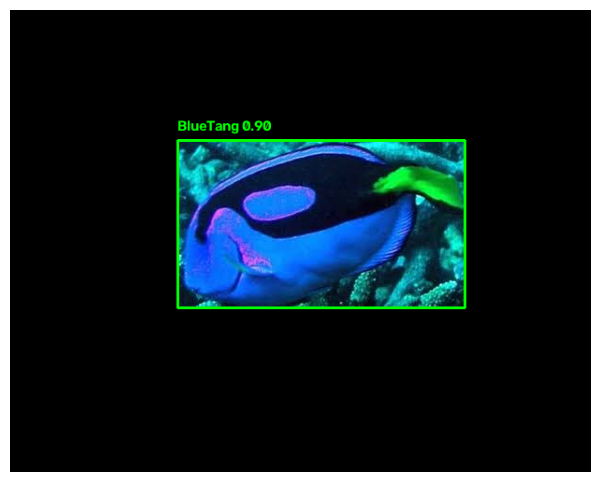

In [70]:
plt.figure(figsize=(10, 6))
plt.imshow(black_bg_main)
plt.axis('off')
plt.show()

```
 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 5.0it/s 8.8s
                   all        700       1197      0.919       0.91      0.944       0.71
              BlueTang          7         23      0.872      0.892       0.92      0.838
         ButterflyFish         10         47      0.959      0.936      0.961      0.551
             ClownFish         28         41      0.924      0.951      0.956      0.687
              GoldFish         62        134      0.869      0.937       0.95      0.722
               Gourami        188        210      0.983          1      0.992      0.915
            MorishIdol         23         31          1      0.995      0.995      0.729
             PlatyFish         50        102      0.822      0.804      0.898      0.655
     RibbonedSweetlips         22         67       0.83      0.896      0.944      0.712
ThreeStripedDamselfish         79        108      0.929      0.965      0.986      0.795
         YellowCichlid         22         95      0.911      0.621      0.772        0.4
            YellowTang         45         80      0.949      0.925       0.96      0.673
             ZebraFish        164        259      0.984      0.996      0.995      0.848
```

## all 94.4% of accuracy - a normal result